In [37]:

from langgraph.graph import StateGraph,START,END
from dotenv import load_dotenv  
from langchain_groq import ChatGroq 
from typing import TypedDict,Literal
from langchain.prompts import PromptTemplate 
from pydantic import BaseModel ,Field
load_dotenv()

True

In [38]:
#lets load the llm model 
llm=ChatGroq(model='Llama3-70b-8192') 
# llm.invoke('hi').content
# "Hi! It's nice to meet you. Is there something I can help you with or would you like to chat?"

In [39]:
#in our workflow first we have to get the sentiment from the given text 
#for that lets create a structured llm 
class SentimentSchema(BaseModel):
    sentiment: Literal['Positive','Negative']=Field(description='The sentiment of given text')

In [40]:
structured_llm=llm.with_structured_output(SentimentSchema)


In [41]:
#lets create a prompt for this 
prompt=PromptTemplate.from_template('''you are sentiment predicter and you have to predict the sentiment of given text
                      \n TEXT  --{text}''')

#lets make a chain for this work 
chain=prompt|structured_llm 


In [42]:
# chain.invoke({'text':'this product is very good and i like it'}).sentiment
chain.invoke({'text':'This product is very pathetic and i hate this product'}).sentiment

'Negative'

In [43]:
#lets also create a structured schema for the run diagnosis function 
class DiagnosisSchema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description='The category of issue mentioned in the review')
    
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description='The emotional tone expressed by the user')
    
    urgency: Literal["low", "medium", "high"] = Field(description='How urgent or critical the issue appears to be')
    
diagnosis_llm=llm.with_structured_output(DiagnosisSchema)
    

In [44]:
#In our workflow first we have to return the sentiment of the given text 
#lets define the state for our graph 
class Review_state(TypedDict):
    review: str 
    sentiment: Literal['Positive','Negative']
    diagnosis: dict 
    response: str 
    

In [45]:
#define the logic for the prediction of the sentiment 
def Predict_sentiment(state: Review_state)-> Review_state:
    review=state['review']
    sentiment=chain.invoke({'text':review}).sentiment 
    state['sentiment']=sentiment 
    return state 


#define the conditional node 
#if the sentiment is positive then we have to return the response directly 
#but if the sentiment is negative we have to run diagnosis 
#lets make a conditional node to check sentiment 
def check_sentiment(state: Review_state)->  Literal['positive_response','run_diagnosis']:
    if state['sentiment']=='Positive':
        return "positive_response" 
    else:
        return 'run_diagnosis' 
    
    


#lets make the remaining function 
def Positive_response(state: Review_state)-> Review_state: 
    prompt=f'write a warm thankyou message in the response to this review \n {state['review']} . Also , kindly ask the user to leave feedback on our website'
    response=llm.invoke(prompt).content 
    # return {'response':response} 
    state['response']=response 
    return state 





def Run_diagnosis(state: Review_state)-> Review_state: 
    prompt= f'Diagnosis this negative review: \n {state['review']} \n "return issue_type,tone,and urgency'
    response= diagnosis_llm.invoke(prompt) #its response is a json so we convert into the dictionary 
    return {'diagnosis':response.model_dump()}


def Negative_response(state: Review_state)-> Review_state: 
    diagnosis=state['diagnosis']
    prompt = f"""You are a support assistant.
The user had a '{diagnosis['issue_type']}' issue, sounded '{diagnosis['tone']}', and marked urgency as '{diagnosis['urgency']}'.
Write an empathetic, helpful resolution message.
"""
    response=llm.invoke(prompt).content 
    return {'response':response}

In [46]:
#lets create the graph 
graph=StateGraph(Review_state)



#lets add the node in our graph 
graph.add_node('predict_sentiment',Predict_sentiment)
graph.add_node('run_diagnosis',Run_diagnosis)
graph.add_node('positive_response',Positive_response) 
graph.add_node('negative_response',Negative_response) 



#lets add edges in it 
graph.add_edge(START,'predict_sentiment') 
graph.add_conditional_edges('predict_sentiment',check_sentiment) 

graph.add_edge('run_diagnosis','negative_response') 

graph.add_edge('negative_response',END) 

graph.add_edge('positive_response',END)


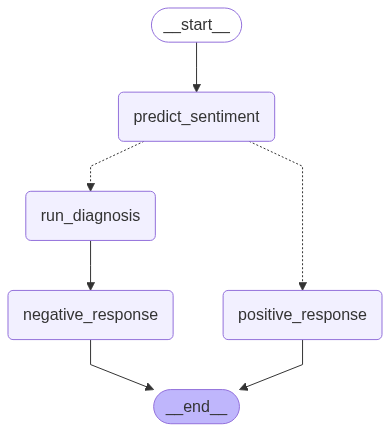

In [47]:
workflow=graph.compile()
workflow

In [ ]:
user_review='this product is very good and i used it for last 2 months '
initial_state={'review':user_review}
final_state=workflow.invoke(initial_state)
print(final_state)

{'review': 'this product is very good and i used it for last 2 months ', 'sentiment': 'Positive', 'response': 'Here\'s a warm thank-you message in response to the review:\n\n"Dear [Customer\'s Name],\n\nWe\'re absolutely thrilled to hear that you\'ve had a great experience with our product over the past two months! It means the world to us that you\'ve found it to be useful and effective. We\'re grateful for customers like you who take the time to share their honest feedback with us.\n\nAs a small favor, we\'d love it if you could also share your feedback on our website. Your review would help others make informed decisions and would mean a lot to our team. You can leave your feedback by clicking on this link: [insert link to website feedback page].\n\nOnce again, thank you so much for your kind words and for choosing our product. We\'re honored to have you as a customer and hope to continue serving you well in the future!\n\nBest regards, [Your Name]"'}


In [49]:
final_state['response']

'Here\'s a warm thank-you message in response to the review:\n\n"Dear [Customer\'s Name],\n\nWe\'re absolutely thrilled to hear that you\'ve had a great experience with our product over the past two months! It means the world to us that you\'ve found it to be useful and effective. We\'re grateful for customers like you who take the time to share their honest feedback with us.\n\nAs a small favor, we\'d love it if you could also share your feedback on our website. Your review would help others make informed decisions and would mean a lot to our team. You can leave your feedback by clicking on this link: [insert link to website feedback page].\n\nOnce again, thank you so much for your kind words and for choosing our product. We\'re honored to have you as a customer and hope to continue serving you well in the future!\n\nBest regards, [Your Name]"'